In [2]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex03_segment_full_pitch', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'selected_idxs': [0, 3, 4, 5]}, 'pitch_calibration_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'width': 1280, 'height': 720}, 'spiideo_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from dataobjects.pitch import Pitch, PitchKeypointMapping

from datamodules.calibration.field_pitch import PitchCalibrationDataModule, PitchCalibrationDatasetArgs, PitchCalibrationDataModule
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.calibration.calibration import CalibrationDataModule, CalibrationDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs

from models.field_registration import Segmentation

spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pitch_calibration_datamodule = PitchCalibrationDataModule(
    PitchCalibrationDatasetArgs(**config['pitch_calibration_dataset']),
    BaseDataModuleArgs(**config['pitch_calibration_datamodule'])
)

In [4]:
train_ds = pitch_calibration_datamodule.dataset('train')
print(f'Selected images: {len(train_ds)}')

12356 JPEG images imported
Selected images: 4


['field_top_left', 'midfield_top', 'midfield_bottom', 'field_bottom_left']
[[ 599.9464     17.155231]
 [1915.5541    105.02987 ]
 [2521.6543   1451.0555  ]
 [-690.96704   430.5798  ]]
[[ 599   17]
 [1915  105]
 [2521 1451]
 [-690  430]]
['midfield_top', 'field_top_right', 'field_bottom_right', 'midfield_bottom']
[[  1915.5541     105.02987]
 [  4990.918      310.4456 ]
 [-11174.073    -2899.3354 ]
 [  2521.6543    1451.0555 ]]
[[  1915    105]
 [  4990    310]
 [-11174  -2899]
 [  2521   1451]]
['left_penalty_top_left', 'left_penalty_top_right', 'left_penalty_bottom_right', 'left_penalty_bottom_left']
[[ 432.59836   70.74969]
 [ 773.8023   100.63408]
 [ 263.3236   339.5808 ]
 [-162.40372  261.30353]]
[[ 432   70]
 [ 773  100]
 [ 263  339]
 [-162  261]]
['right_penalty_top_left', 'right_penalty_top_right', 'right_penalty_bottom_right', 'right_penalty_bottom_left']
[[ 4387.414     417.13272]
 [ 6428.5366    595.9046 ]
 [66120.19    12448.502  ]
 [11231.414    2356.2537 ]]
[[ 4387   417]


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_40389/1116744881.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


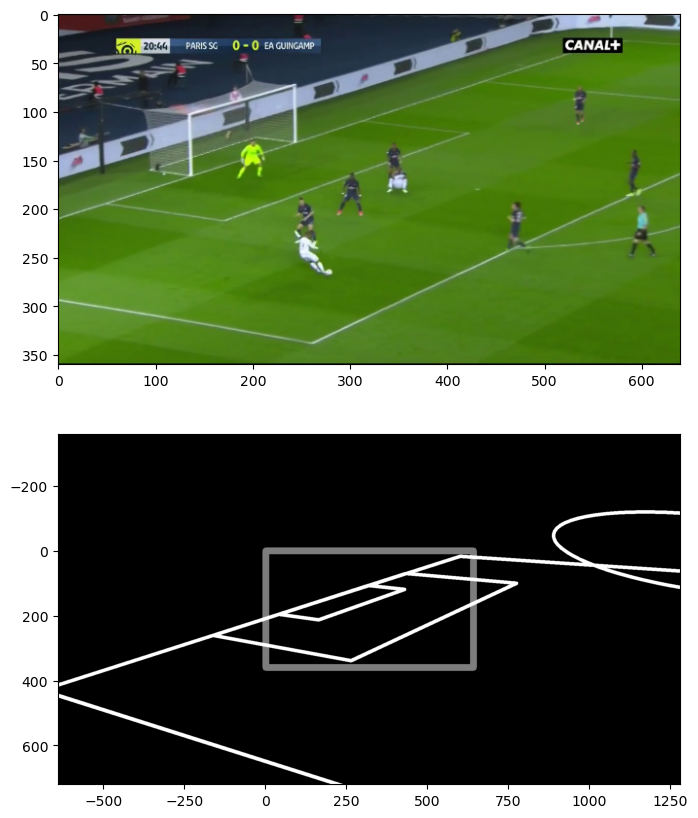

In [16]:
fig, ax = plt.subplots(nrows=2, figsize=(20, 10))

IDX = 3
ax[0].imshow(train_ds[IDX][0])
train_ds[IDX][1].plot(ax=ax[1], scale=1, thickness=10, extra_space_scale=3)
# train_ds[IDX][1].plot_filled(ax=ax[2], thickness=10, scale=1, extra_space_scale=3)

fig.show()

In [6]:
PitchKeypointMapping.BOX_FIELD

(5, 7, 8, 6)

In [7]:
KP_IDX = [
    PitchKeypointMapping.BOX_GOALKEEPER_RIGHT
]

X = train_ds[IDX][1].keypoints.detach().numpy()
# X = Pitch().keypoints.detach().numpy()
X /= X[:, [2]] 

X[KP_IDX].astype('int')

array([[[  772,  6743,     1],
        [  896,  7941,     1],
        [ 2619, 16621,     1],
        [ 1961, 12117,     1]]])

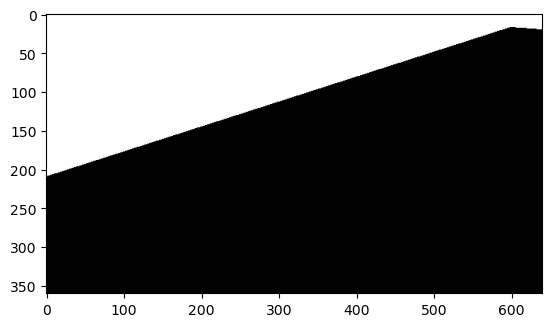

In [8]:
import cv2
pts = np.array([
    [[599, 17], [1915, 105], [2521, 1451], [-690, 430]],
    [[1915, 105], [4990, 310], [-11174, -2899], [2521, 1451]]
], dtype=np.int32)

# cv2.fillPoly expects a list of polygons
img = np.zeros((360,640))
# for poly in pts:
#     img = cv2.fillPoly(img, [poly], 255)
#     plt.imshow(img, cmap='gray')
#     plt.show()

img = cv2.fillPoly(img, pts, 255)
plt.imshow(img, cmap='gray')
plt.show()

# img = cv2.fillPoly(img, pts[:1], 255)


In [9]:
a = np.arange(6)
b = np.arange(10, 16)
b[np.isin(a, [2, 4, 6])]

array([12, 14])

In [10]:
np.logical_and((a < 5), (b < 17))

array([ True,  True,  True,  True,  True, False])

In [11]:
a < 5

array([ True,  True,  True,  True,  True, False])

In [12]:
y0, x0, z0 = np.meshgrid(
    np.arange(10),
    np.arange(20),
    1
)

H = 2 * np.eye(3)
H

array([[2., 0., 0.],
       [0., 2., 0.],
       [0., 0., 2.]])

In [13]:
pts_0 = np.stack([y0, x0, z0], axis=-1).reshape(-1, 3)
pts_1 = pts_0 @ H.T
(pts_1[:, [0, 1]] / pts_1[:, [2]]).T

array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,
         3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,
         9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,
         2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,
         5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,
         8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,
         1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,
         4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,
         7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,
         0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,
         3.,  4.,  5.,  6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.,  9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,
         9.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.

In [14]:
x0

array([[[ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0],
        [ 0]],

       [[ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1],
        [ 1]],

       [[ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2],
        [ 2]],

       [[ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3],
        [ 3]],

       [[ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4],
        [ 4]],

       [[ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5],
        [ 5]],

       [[ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6],
        [ 6]],

      